In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_validate, cross_val_score
from metagen.framework import Domain
from metagen.metaheuristics.rs import RandomSearch
from sklearn.ensemble import RandomForestRegressor
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import plot_performance_analysis, shifted_mape
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
regression_domain = Domain()
regression_domain.define_integer("estimator1__n_estimators", 50, 100)
regression_domain.define_integer("estimator1__max_depth", 15, 50)
regression_domain.define_integer("estimator1__min_samples_split", 3, 15)
regression_domain.define_real("estimator1__max_features", 0.8, 1.0)
regression_domain.define_integer("estimator2__n_estimators", 200, 250)
regression_domain.define_integer("estimator2__max_depth", 4, 10)
regression_domain.define_real("estimator2__learning_rate", 0.1, 0.2)
regression_domain.define_real("estimator2__colsample_bytree", 0.4, 0.5)

In [5]:
def regression_fitness(solution):
    model = ElectricSequentialRegressor(
        RandomForestRegressor(n_estimators=solution["estimator1__n_estimators"],
                              max_depth=solution["estimator1__max_depth"],
                              min_samples_split=solution["estimator1__min_samples_split"],
                              max_features=solution["estimator1__max_features"], n_jobs=1, random_state=42),
        XGBRegressor(n_estimators=solution["estimator2__n_estimators"],
                    max_depth=solution["estimator2__max_depth"],
                    learning_rate=solution["estimator2__learning_rate"],
                     colsample_bytree=solution["estimator2__colsample_bytree"],
                     objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1)

    mse = cross_val_score(model, x_train, y_train, scoring="neg_mean_squared_error",
                          cv=TimeSeriesSplit(n_splits=5), n_jobs=-1).mean() * -1
    return mse

In [6]:
best_solution = RandomSearch(regression_domain, regression_fitness, population_size=2, max_iterations=10).run()

In [7]:
best_solution

F = 0.009422541667448367	{estimator1__max_depth = 48 , estimator1__max_features = 0.8439447939933842 , estimator1__min_samples_split = 8 , estimator1__n_estimators = 55 , estimator2__colsample_bytree = 0.4687907182054175 , estimator2__learning_rate = 0.1211375185912773 , estimator2__max_depth = 5 , estimator2__n_estimators = 239}

<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [8]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_model = ElectricSequentialRegressor(
        RandomForestRegressor(n_estimators=best_solution["estimator1__n_estimators"],
                              max_depth=best_solution["estimator1__max_depth"],
                              min_samples_split=best_solution["estimator1__min_samples_split"],
                              max_features=best_solution["estimator1__max_features"], n_jobs=1, random_state=42),
        XGBRegressor(n_estimators=best_solution["estimator2__n_estimators"],
                    max_depth=best_solution["estimator2__max_depth"],
                    learning_rate=best_solution["estimator2__learning_rate"],
                     colsample_bytree=best_solution["estimator2__colsample_bytree"],
                     objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1)

best_model.fit(x_train, y_train)
predictions = best_model.predict(x_test)

In [9]:
random_MAE = mean_absolute_error(y_test, predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, predictions, multioutput='raw_values')

In [10]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001693,0.001691,0.001699,0.001728,0.001718,0.001699,0.001708,0.001694,0.001715,0.001708,0.001701,0.001524,0.001494,0.226838,0.006657
MAPE,0.000858,0.000858,0.000862,0.000876,0.000872,0.000862,0.000867,0.000859,0.000870,0.000866,0.000863,0.000770,0.000755,0.026150,0.006256
R2,0.973793,0.974151,0.974071,0.973418,0.973605,0.974042,0.973906,0.974256,0.973760,0.973900,0.974138,0.974833,0.975639,0.978381,0.882300


In [11]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001693,0.001691,0.001699,0.001728,0.001718,0.001699,0.001708,0.001694,0.001715,0.001708,0.001701,0.001524,0.001494,0.226838,6.657069e-03
MAPE,0.001742,0.001741,0.001750,0.001779,0.001770,0.001750,0.001759,0.001744,0.001766,0.001759,0.001752,0.001557,0.001527,0.030595,9.340818e+12
R2,0.973793,0.974151,0.974071,0.973418,0.973605,0.974042,0.973906,0.974256,0.973760,0.973900,0.974138,0.974833,0.975639,0.978381,8.823004e-01


In [12]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001675,0.226838,0.006657
MAPE,0.000849,0.026150,0.006256
R2,0.974116,0.978381,0.882300


In [13]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001675,0.226838,6.657069e-03
MAPE,0.001723,0.030595,9.340818e+12
R2,0.974116,0.978381,8.823004e-01


**Validación Cruzada para Contrastación de Resultados**

In [14]:
evaluate_model_shifted = ElectricSequentialRegressor(
        RandomForestRegressor(n_estimators=best_solution["estimator1__n_estimators"],
                              max_depth=best_solution["estimator1__max_depth"],
                              min_samples_split=best_solution["estimator1__min_samples_split"],
                              max_features=best_solution["estimator1__max_features"], n_jobs=1, random_state=42),
        XGBRegressor(n_estimators=best_solution["estimator2__n_estimators"],
                    max_depth=best_solution["estimator2__max_depth"],
                    learning_rate=best_solution["estimator2__learning_rate"],
                     colsample_bytree=best_solution["estimator2__colsample_bytree"],
                     objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1)
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.010916966918661501
MAE: 0.017837273598063485
MAPE: 0.002998155062992644
R2: 0.9691854744330126


In [15]:
evaluate_model = ElectricSequentialRegressor(
        RandomForestRegressor(n_estimators=best_solution["estimator1__n_estimators"],
                              max_depth=best_solution["estimator1__max_depth"],
                              min_samples_split=best_solution["estimator1__min_samples_split"],
                              max_features=best_solution["estimator1__max_features"], n_jobs=1, random_state=42),
        XGBRegressor(n_estimators=best_solution["estimator2__n_estimators"],
                    max_depth=best_solution["estimator2__max_depth"],
                    learning_rate=best_solution["estimator2__learning_rate"],
                     colsample_bytree=best_solution["estimator2__colsample_bytree"],
                     objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1)
evaluate_scoring = { # EVALUACIÓN SIN DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.010916966918661501
MAE: 0.017837273598063485
MAPE: 606948473737.3972
R2: 0.9691854744330126


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [16]:
joblib.dump(best_model, '../models/ESR_MO_Best_Model.pkl')

['../models/ESR_MO_Best_Model.pkl']

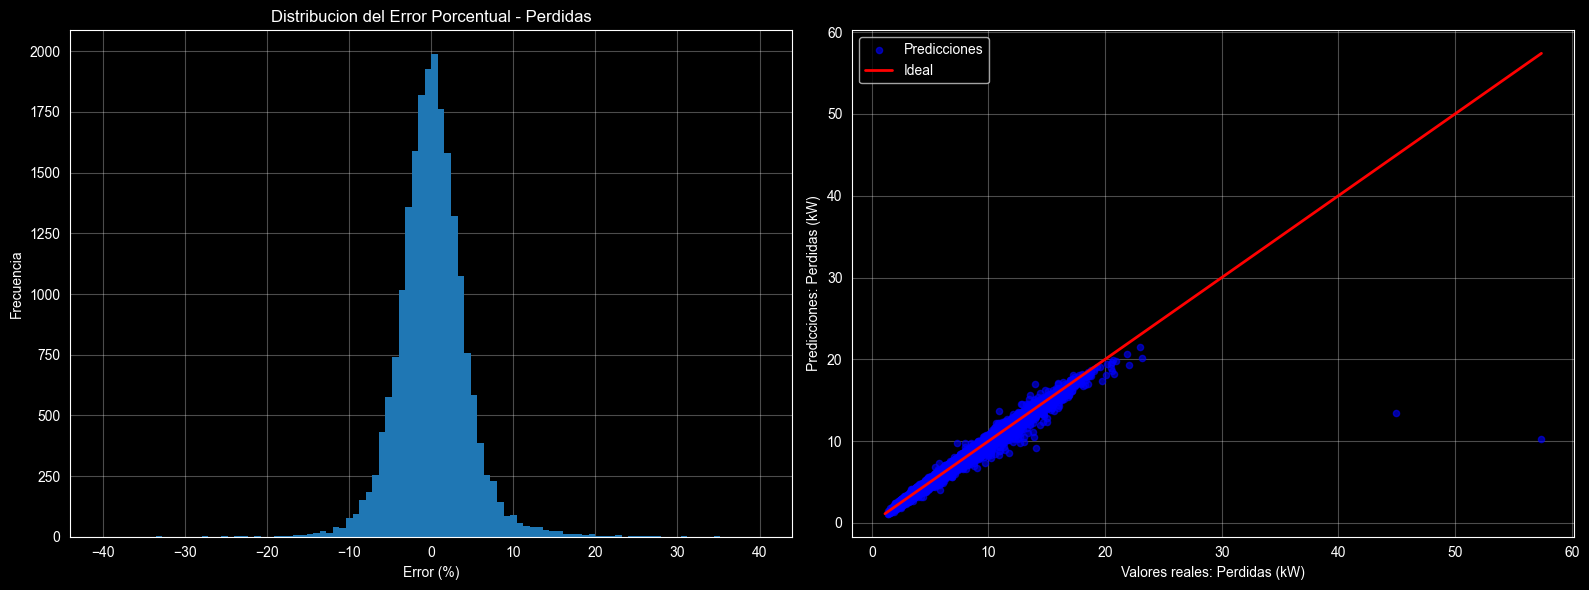

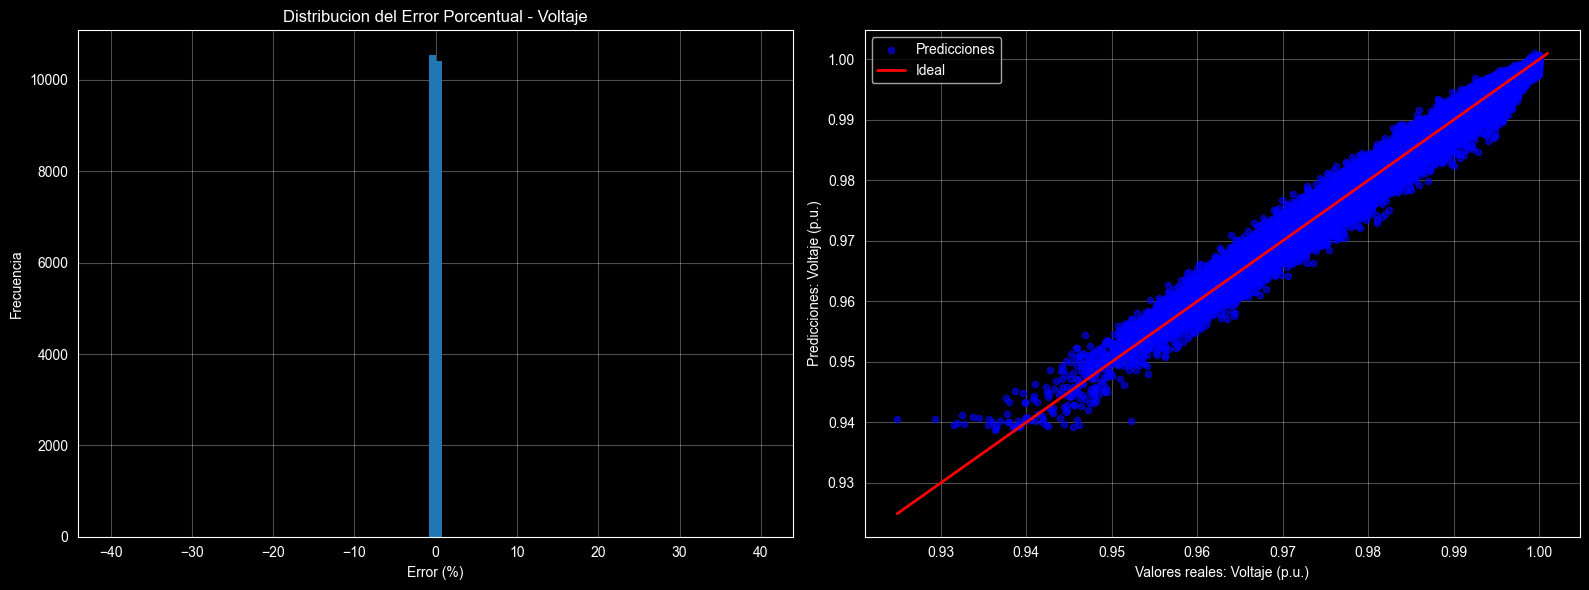

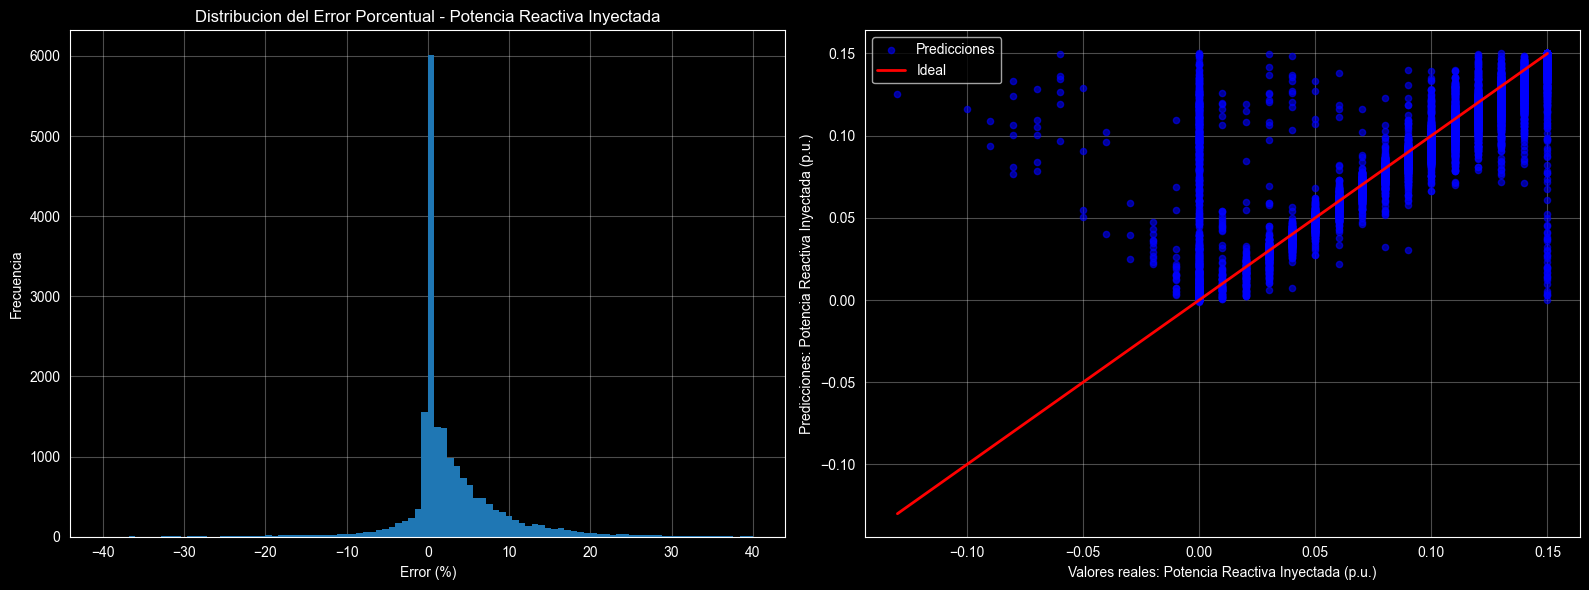

In [17]:
plot_performance_analysis(
    y_test['PERD'],
    predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/BestModel/ESR_MO_Best_Model_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/BestModel/ESR_MO_Best_Model_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/BestModel/ESR_MO_Best_Model_QGen.png'
)